In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import numpy as np
import json


Processing PCA:   0%|          | 0/8 [00:00<?, ?it/s]

Processing PCA:  12%|█▎        | 1/8 [00:16<01:57, 16.85s/it]

PCA - 2 components: RMSE = 0.05, NMSE = 0.04


Processing PCA:  25%|██▌       | 2/8 [00:33<01:38, 16.46s/it]

PCA - 4 components: RMSE = 0.05, NMSE = 0.03


...

Processing Autoencoder (Sparse):  88%|████████▊ | 7/8 [01:28<00:12, 12.72s/it]

Autoencoder (Sparse) - 100 components: RMSE = 0.01, NMSE = 0.00


Processing Autoencoder (Sparse): 100%|██████████| 8/8 [01:41<00:00, 12.72s/it]

Autoencoder (Sparse) - 128 components: RMSE = 0.01, NMSE = 0.00


FileNotFoundError: [Errno 2] No such file or directory: '../data/plots/rmse_vs._#_of_dimensions.png'

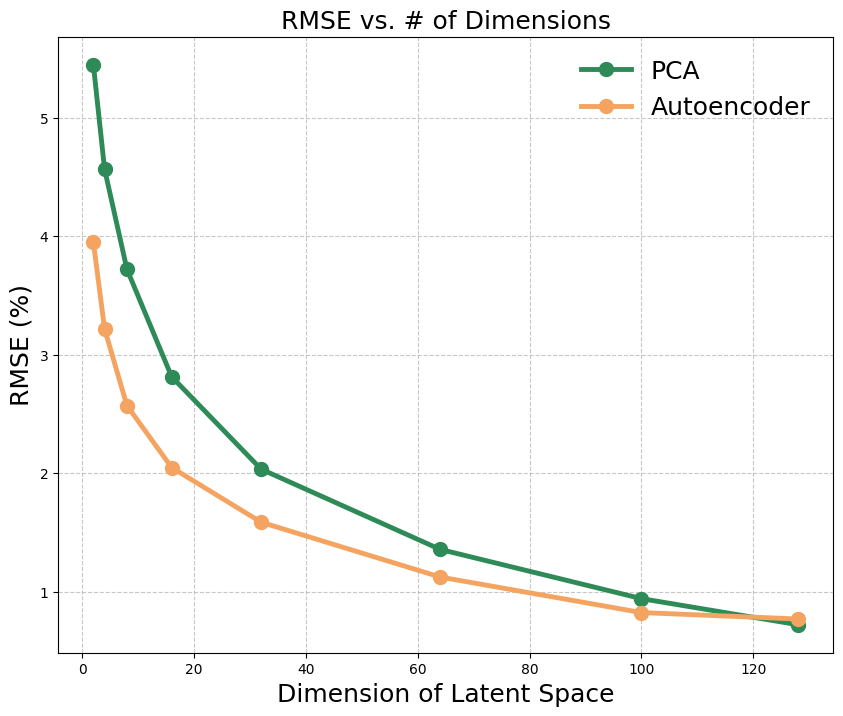

In [ ]:
# --- Utility Functions ---

def compute_errors(original, reconstructed):
    """Compute RMSE and NMSE between original and reconstructed data."""
    error = original - reconstructed
    rmse = np.sqrt(np.mean(error ** 2))
    nmse = ((error ** 2).mean(axis=1) / (original ** 2).mean(axis=1)).mean()
    return rmse, nmse

def load_reconstructed_data(file_path, index_col="ID"):
    """Load reconstructed data from a CSV file."""
    return pd.read_csv(file_path, index_col=index_col)

# --- Error Caching ---

def save_errors(errors, filepath):
    with open(filepath, "w") as f:
        json.dump(errors, f)

def load_errors(filepath):
    with open(filepath, "r") as f:
        return json.load(f)
    
# --- Processing Functions ---

def process_reconstruction(label, file_pattern, bottleneck_sizes, original_data, index_col="ID", inverse_transform=None):
    """Process reconstruction for autoencoder-based methods."""
    metrics = {"rmse": [], "nmse": []}
    #inverse transfrom the data if needed
    if inverse_transform is not None:
        original_data = inverse_transform(original_data)
    for n in tqdm(bottleneck_sizes, desc=f"Processing {label}"):
        reconstructed = load_reconstructed_data(file_pattern.format(n=n), index_col=index_col)
        if inverse_transform is not None:
            reconstructed = inverse_transform(reconstructed)
        # Compute errors
        rmse, nmse = compute_errors(original_data, reconstructed)
        print(f"{label} - {n} components: RMSE = {rmse:.2f}, NMSE = {nmse:.2f}")
        metrics["rmse"].append(rmse)
        metrics["nmse"].append(nmse)
    return metrics

def process_all_methods(original_data, data_path, working_dir, bottleneck_sizes, force_recompute=False):
    cache_path = f"{working_dir}/errors_cache.json"
    if os.path.exists(cache_path) and not force_recompute:
        print(f"Loading cached errors from {cache_path}")
        return load_errors(cache_path)

    errors = {}
    errors["PCA"] = process_reconstruction("PCA", data_path + "PCA/{n}_components.csv", bottleneck_sizes, original_data, index_col="OA")
    errors["Autoencoder"] = process_reconstruction("Autoencoder", f"{working_dir}/census_geodemo__bottleneck_{{n}}_v1__reconstructed_outputs.csv", bottleneck_sizes, original_data, index_col="ID")
    errors["Autoencoder (Sparse)"] = process_reconstruction("Autoencoder (Sparse)", f"{working_dir}/census_geodemo_sparse__bottleneck_{{n}}_v1__reconstructed_outputs.csv", bottleneck_sizes, original_data, index_col="ID")
    # errors["Autoencoder (Mul)"] = process_reconstruction("Autoencoder (Mul)", f"../AE_outputs/engcensus_all/250epoch_scan_mul/census_geodemo__bottleneck_{{n}}_v1__reconstructed_outputs.csv", bottleneck_sizes, original_data, index_col="ID")
    save_errors(errors, cache_path)
    return errors

# --- Plotting ---

def plot_errors(errors, bottleneck_sizes, metric, ylabel, title):
    """Plot errors for different reconstruction methods."""
    colors = ["seagreen", "sandybrown", "#E15759", "#76B7B2", "#59A14F", "#EDC949"]
    plt.figure(figsize=(10, 8))

    for i, (label, data) in enumerate(errors.items()):
        if label =="Autoencoder (Sparse)":
            continue
        if label =="Autoencoder (Mul)":
            continue
        plt.plot(
            bottleneck_sizes, np.array(data[metric])*100,  # Convert to percentage for RMSE
            marker='o', markersize=10, linewidth=3.5,
            label=label, color=colors[i % len(colors)]
        )

    plt.xlabel("Dimension of Latent Space", fontsize=18)
    plt.ylabel(ylabel, fontsize=18)
    plt.title(title, fontsize=18)
    plt.legend(fontsize=18, frameon=False)
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.savefig(f"plots/{title.replace(' ', '_').lower()}.png", dpi=300)
    plt.show()


# --- Configuration ---

bottleneck_sizes = [2, 4, 8, 16, 32, 64, 100, 128]

# --- Load Data Once ---

df_scaled = pd.read_parquet("../data/census_data/engcensus_cleaned_scaled.parquet")
df_scaled.set_index(df_scaled.columns[0], inplace=True)

# --- Process All ---

path = "../AE_outputs/engcensus_all/"
working_dir = path + "250epoch_scan_lin"

errors = process_all_methods(df_scaled, path, working_dir, bottleneck_sizes,force_recompute=True)


# --- Example Plot Calls ---

plot_errors(errors, bottleneck_sizes, "rmse", "RMSE (%)", "RMSE vs. # of Dimensions")
